# THYAO Hisse Senedi Analizi — Veri Bilimi Donem Projesi

**Ogrenci:** Ahmet Melih Çakalgil
**Tema:** Finans & Ekonomi — BIST (THYAO.IS)
**Veri kaynagi:** Yahoo Finance (`yfinance`)

## Arastirma Sorulari

1. THYAO hissesinin son 5 yildaki gunluk getiri dagilimi nasildir ve volatilite
   zaman icinde nasil degismistir?
2. Islem hacmi ile fiyat volatilitesi arasinda bir iliski var midir? Hareketli
   ortalama kesismeleri (golden cross / death cross) anlamli sinyaller uretiyor mu?
3. Teknik gostergeler kullanilarak ertesi gunun yonu (artis/azalis) siniflandirilabilir mi?


## 1. Kutuphanelerin Yuklenmesi

In [24]:
# Veri cekme ve islem icin temel kutuphaneler
import yfinance as yf
import pandas as pd
import numpy as np

# Gorsellestirme
import matplotlib.pyplot as plt
import seaborn as sns

# Modelleme
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Grafik stili - tum notebook boyunca tutarli gorunum icin
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Kutuphaneler basariyla yuklendi.")


Kutuphaneler basariyla yuklendi.


## 2. Veri Toplama

THYAO.IS sembolu icin Yahoo Finance'ten son 5 yillik gunluk (daily) fiyat ve
hacim verisi cekilir. `auto_adjust=True` kullanilarak temettu/bolunme
duzeltmeleri otomatik uygulanir, boylece fiyat serisinde yapay siciramalar
olmaz.

In [25]:
# THYAO.IS son 5 yillik gunluk veri
ticker = "THYAO.IS"
df_raw = yf.download(ticker, period="5y", interval="1d", auto_adjust=True)

print(f"Indirilen satir sayisi: {len(df_raw)}")
print(f"Tarih araligi: {df_raw.index.min().date()} -> {df_raw.index.max().date()}")
df_raw.head()


[*********************100%***********************]  1 of 1 completed

Indirilen satir sayisi: 1251
Tarih araligi: 2021-06-28 -> 2026-06-26


Price,Close,High,Low,Open,Volume
Ticker,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS
Date,,,,,
2021-06-28,13.539614,14.057363,13.471232,13.969443,70742415
2021-06-29,13.080480,13.481002,12.973022,13.451696,88067148
2021-06-30,13.060942,13.246550,13.002329,13.187937,72427976
2021-07-01,13.432158,13.432158,13.060941,13.100017,95675692
2021-07-02,13.422388,13.529846,13.314931,13.422388,102222132


In [26]:
# Ham veriyi kaydet (tekrar indirmeye gerek kalmasin diye)
df_raw.to_csv("../data/thyao_raw.csv")
df_raw.tail()


Price,Close,High,Low,Open,Volume
Ticker,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS,THYAO.IS
Date,,,,,
2026-06-22,324.75,329.00,324.25,328.50,30581205
2026-06-23,325.00,327.25,321.50,323.50,36591935
2026-06-24,324.75,328.25,323.25,325.25,41954740
2026-06-25,328.50,333.25,327.50,327.50,53199419
2026-06-26,330.75,332.25,327.50,328.50,35151597


## 3. Veri Temizleme

Bu bolumde uc sey kontrol edilir:
1. **Eksik veri** — borsa tatil gunlerinde veri olmaz, bu normal; ama sutun
   icinde NaN var mi bakilir.
2. **Tip donusumu** — sutunlarin sayisal (float) tipte oldugundan emin olunur.
3. **Aykiri deger** — gunluk getiri uzerinden, istatistiksel olarak asiri
   uc degerler (örn. %20'den fazla tek gunluk hareket gibi gercek olmayan
   degerler) kontrol edilir. Not: gercek piyasa olaylarindan kaynaklanan
   buyuk hareketler (örn. kriz gunleri) silinmez, sadece veri hatasi olabilecek
   imkansiz degerler aranir.

In [27]:
# yfinance multi-index sutun donduruyorsa duzlestir
if isinstance(df_raw.columns, pd.MultiIndex):
    df_raw.columns = df_raw.columns.get_level_values(0)

df = df_raw.copy()

# Eksik veri kontrolu
print("Eksik deger sayisi (sutun bazinda):")
print(df.isna().sum())


Eksik deger sayisi (sutun bazinda):
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [28]:
# Eksik degerler varsa: once ileri doldurma (bir onceki gunun degeri ile),
# cunku fiyat serilerinde rastgele silme/ortalama ile doldurma yaniltici olur
if df.isna().sum().sum() > 0:
    df = df.ffill()
    print("Eksik degerler ileri doldurma (forward fill) ile dolduruldu.")
else:
    print("Eksik deger bulunmadi.")

# Tip donusumu kontrolu
print("\nSutun tipleri:")
print(df.dtypes)


Eksik deger bulunmadi.

Sutun tipleri:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [29]:
# Gunluk getiri hesapla (aykiri deger kontrolu icin gerekli)
df["Gunluk_Getiri"] = df["Close"].pct_change()

# Istatistiksel ozet
print(df["Gunluk_Getiri"].describe())

# Olasi veri hatasi olabilecek asiri degerleri tespit et (+-%50 ustu gunluk
# hareket BIST icin teorik olarak tavan/taban limitleri asar, gercek olamaz)
aykiri = df[df["Gunluk_Getiri"].abs() > 0.5]
print(f"\nSupheli (>%50 gunluk hareket) satir sayisi: {len(aykiri)}")
aykiri


count    1250.000000
mean        0.002899
std         0.026223
min        -0.099819
25%        -0.012612
50%         0.000819
75%         0.016033
max         0.216522
Name: Gunluk_Getiri, dtype: float64

Supheli (>%50 gunluk hareket) satir sayisi: 0


Price,Close,High,Low,Open,Volume,Gunluk_Getiri
Date,,,,,,


In [30]:
# Aykiri deger bulunursa cikar (BIST gunluk tavan/taban genelde %10 civarinda,
# %50 ustu bir hareket veri hatasidir, gercek piyasa hareketi degildir)
df = df[df["Gunluk_Getiri"].abs() <= 0.5].copy()

# Ilk satirdaki NaN getiriyi temizle (pct_change ilk satirda NaN doner)
df = df.dropna(subset=["Gunluk_Getiri"])

print(f"Temizleme sonrasi satir sayisi: {len(df)}")
df.describe()


Temizleme sonrasi satir sayisi: 1250


Price,Close,High,Low,Open,Volume,Gunluk_Getiri
count,1250.000000,1250.000000,1250.000000,1250.000000,1.250000e+03,1250.000000
mean,196.444564,199.383217,193.968485,196.681353,5.688669e+07,0.002899
std,112.237628,113.655515,111.206629,112.489710,4.173296e+07,0.026223
min,11.908217,11.986370,11.820299,11.878911,0.000000e+00,-0.099819
25%,73.266314,75.012496,71.581192,73.876860,2.928510e+07,-0.012612
50%,249.056625,254.234096,246.270124,249.935817,4.110194e+07,0.000819
75%,292.000000,295.934838,288.913503,292.706707,7.144985e+07,0.016033
max,347.750000,352.500000,345.000000,349.750000,2.696631e+08,0.216522


## 4. Teknik Gosterge ve Feature Uretimi

Modelleme ve EDA icin kullanilacak teknik gostergeler hesaplanir:

- **SMA (Simple Moving Average):** 20 ve 50 gunluk hareketli ortalamalar —
  kisa ve uzun vadeli trend yonunu gosterir.
- **RSI (Relative Strength Index):** 14 gunluk, hissenin "asiri alim/asiri
  satim" bolgesinde olup olmadigini gosteren 0-100 araliginda bir gosterge.
- **Hacim degisimi:** gunluk islem hacminin onceki gune gore yuzde degisimi.
- **Volatilite:** 20 gunluk hareketli standart sapma (getiri uzerinden).

In [31]:
# Hareketli ortalamalar (trend gostergeleri)
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# RSI (Relative Strength Index) hesaplama - 14 gunluk standart pencere
delta = df["Close"].diff()
kazanc = delta.where(delta > 0, 0.0)
kayip = -delta.where(delta < 0, 0.0)

ortalama_kazanc = kazanc.rolling(window=14).mean()
ortalama_kayip = kayip.rolling(window=14).mean()

rs = ortalama_kazanc / ortalama_kayip
df["RSI_14"] = 100 - (100 / (1 + rs))

# Hacim degisimi (yuzde)
df["Hacim_Degisim"] = df["Volume"].pct_change()

# 20 gunluk volatilite (gunluk getirinin hareketli standart sapmasi)
df["Volatilite_20"] = df["Gunluk_Getiri"].rolling(window=20).std()

df[["Close", "SMA_20", "SMA_50", "RSI_14", "Hacim_Degisim", "Volatilite_20"]].tail()


Price,Close,SMA_20,SMA_50,RSI_14,Hacim_Degisim,Volatilite_20
Date,,,,,,
2026-06-22,324.75,305.8375,308.730,70.204082,-0.560723,0.020116
2026-06-23,325.00,307.2500,308.840,73.931624,0.196550,0.020068
2026-06-24,324.75,308.6500,308.870,72.321429,0.146557,0.020078
2026-06-25,328.50,310.2375,309.105,77.631579,0.268019,0.020102
2026-06-26,330.75,311.9375,309.240,78.389831,-0.339248,0.020065


In [32]:
# Once sonsuz (inf) degerleri NaN'a cevir - RSI hesaplamasinda ortalama_kayip=0
# oldugu durumlarda (14 gunde hic dusus olmamissa) bolme sonsuz (inf) verir
df = df.replace([np.inf, -np.inf], np.nan)

# Hareketli ortalama hesaplarindan kaynaklanan baslangic NaN satirlarini ve
# yukarida inf'ten donusen NaN satirlarini cikar
df_model = df.dropna().copy()

# Kontrol: artik sonsuz deger kalmadigini dogrula
assert np.isfinite(df_model.select_dtypes(include=[np.number])).all().all(), "Hala sonsuz deger var!"
print(f"Feature uretimi sonrasi kullanilabilir satir sayisi: {len(df_model)}")

# Temizlenmis veriyi kaydet
df_model.to_csv("../data/thyao_temiz.csv")


Feature uretimi sonrasi kullanilabilir satir sayisi: 1198


## 5. Kesifsel Veri Analizi (EDA)

Asagida 4 farkli gorsellestirme turu kullanilmistir:
1. Zaman serisi cizgi grafigi (fiyat + hareketli ortalamalar)
2. Histogram (gunluk getiri dagilimi)
3. Isi haritasi / korelasyon matrisi (feature'lar arasi iliski)
4. Saçilim grafigi (hacim degisimi vs volatilite)

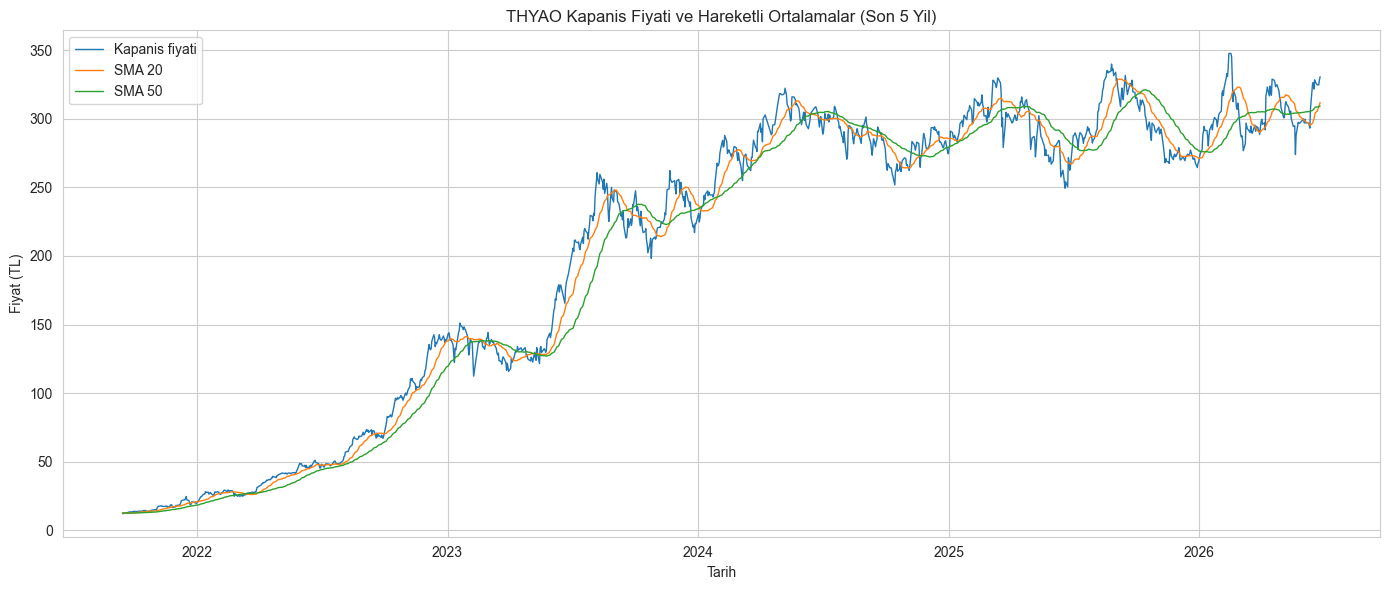

In [33]:
# 1) Zaman serisi: fiyat + hareketli ortalamalar
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_model.index, df_model["Close"], label="Kapanis fiyati", linewidth=1)
ax.plot(df_model.index, df_model["SMA_20"], label="SMA 20", linewidth=1)
ax.plot(df_model.index, df_model["SMA_50"], label="SMA 50", linewidth=1)
ax.set_title("THYAO Kapanis Fiyati ve Hareketli Ortalamalar (Son 5 Yil)")
ax.set_xlabel("Tarih")
ax.set_ylabel("Fiyat (TL)")
ax.legend()
plt.tight_layout()
plt.show()


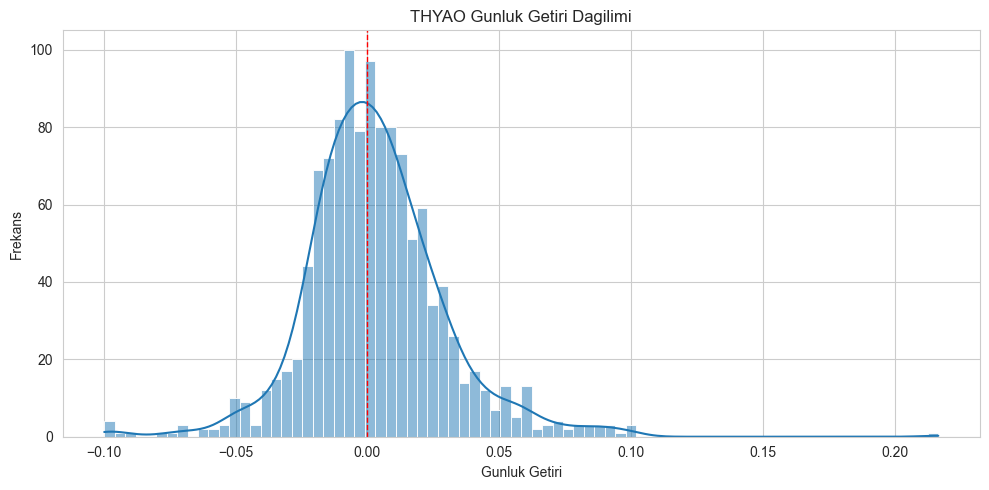

Ortalama gunluk getiri: 0.00312
Standart sapma: 0.02655
Carpiklik (skewness): 0.707
Kurtosis: 5.112


In [34]:
# 2) Histogram: gunluk getiri dagilimi
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_model["Gunluk_Getiri"], bins=80, kde=True, ax=ax)
ax.set_title("THYAO Gunluk Getiri Dagilimi")
ax.set_xlabel("Gunluk Getiri")
ax.set_ylabel("Frekans")
ax.axvline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

print(f"Ortalama gunluk getiri: {df_model['Gunluk_Getiri'].mean():.5f}")
print(f"Standart sapma: {df_model['Gunluk_Getiri'].std():.5f}")
print(f"Carpiklik (skewness): {df_model['Gunluk_Getiri'].skew():.3f}")
print(f"Kurtosis: {df_model['Gunluk_Getiri'].kurt():.3f}")


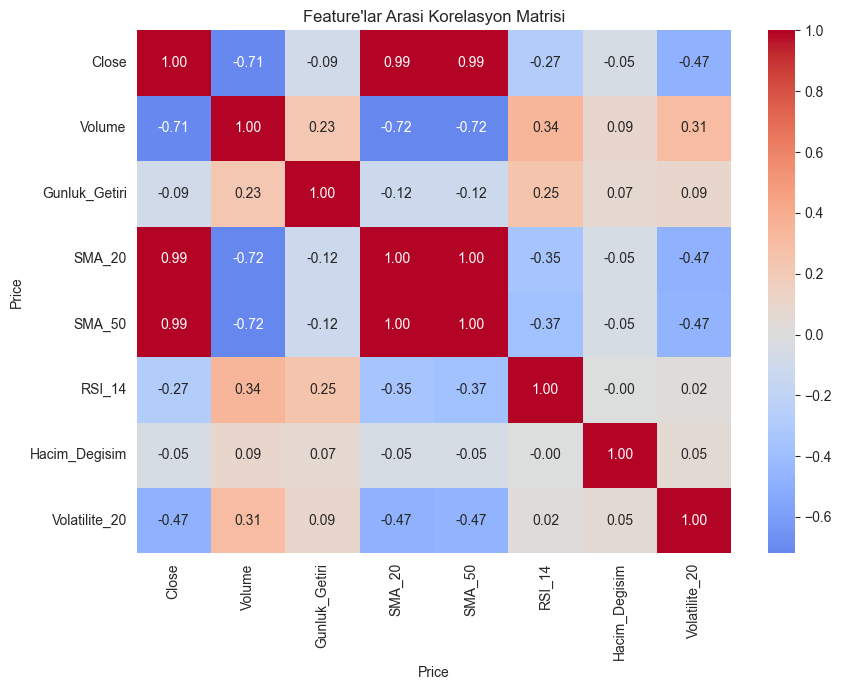

In [35]:
# 3) Korelasyon isi haritasi
feature_cols = ["Close", "Volume", "Gunluk_Getiri", "SMA_20", "SMA_50",
                 "RSI_14", "Hacim_Degisim", "Volatilite_20"]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df_model[feature_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax)
ax.set_title("Feature'lar Arasi Korelasyon Matrisi")
plt.tight_layout()
plt.show()


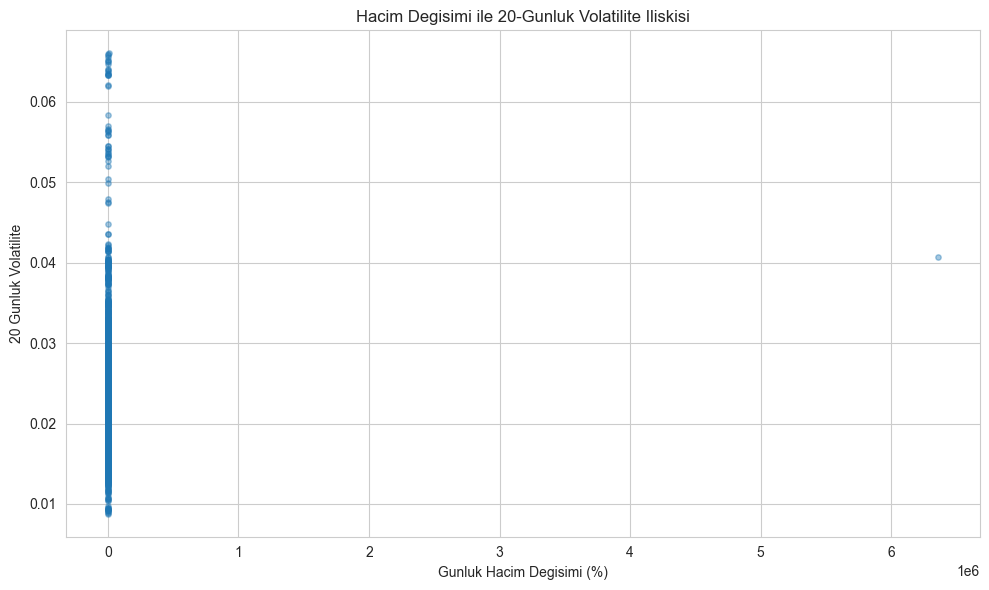

Hacim degisimi - Volatilite korelasyonu: 0.047


In [36]:
# 4) Sacilim grafigi: hacim degisimi vs volatilite
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_model["Hacim_Degisim"], df_model["Volatilite_20"], alpha=0.4, s=15)
ax.set_title("Hacim Degisimi ile 20-Gunluk Volatilite Iliskisi")
ax.set_xlabel("Gunluk Hacim Degisimi (%)")
ax.set_ylabel("20 Gunluk Volatilite")
plt.tight_layout()
plt.show()

korelasyon = df_model["Hacim_Degisim"].corr(df_model["Volatilite_20"])
print(f"Hacim degisimi - Volatilite korelasyonu: {korelasyon:.3f}")


## 6. Arastirma Sorusu 1: Getiri Dagilimi ve Volatilite Zaman Icinde Nasil Degisti?

Yillik bazda volatilite hesaplanarak hangi donemlerde THYAO'nun daha
oynak (volatil) oldugu incelenir.

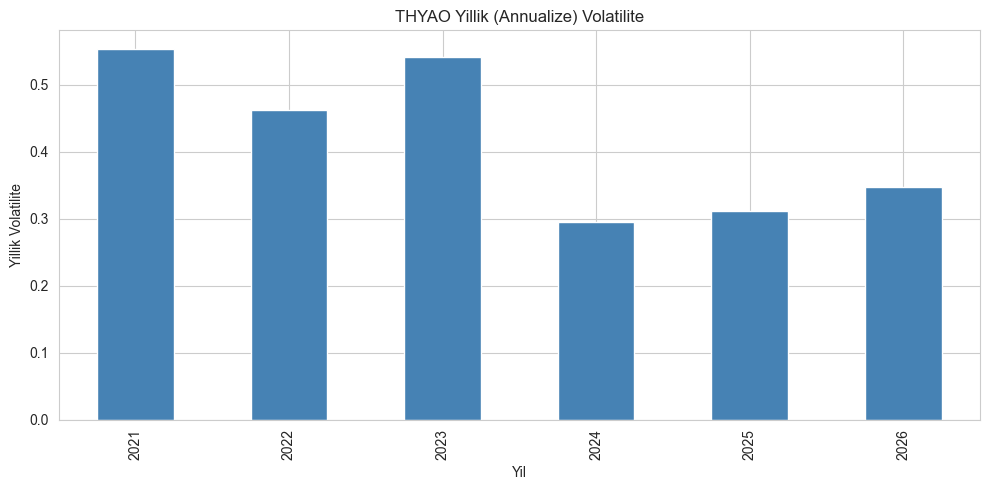

Yil
2021    0.553426
2022    0.462473
2023    0.540678
2024    0.294938
2025    0.311489
2026    0.347712
Name: Gunluk_Getiri, dtype: float64


In [37]:
# Yillik volatilite (gunluk getirinin yillik standart sapmasi, sqrt(252) ile yillik hale getirilir)
df_model["Yil"] = df_model.index.year
yillik_volatilite = df_model.groupby("Yil")["Gunluk_Getiri"].std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(10, 5))
yillik_volatilite.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("THYAO Yillik (Annualize) Volatilite")
ax.set_xlabel("Yil")
ax.set_ylabel("Yillik Volatilite")
plt.tight_layout()
plt.show()

print(yillik_volatilite)


**Yorum:** Grafikte en yüksek yıllık volatilitenin 2021 (%55,3) ve 2023 (%54,1) yıllarında görüldüğü, 2024'ten itibaren ise belirgin bir şekilde düştüğü (2024: %29,5, 2025: %31,1) görülmektedir. Bu durumun, THYAO'nun bu dönemde kapanış fiyatının ~15 TL seviyelerinden ~300 TL bandına sıçradığı güçlü yükseliş trendiyle örtüştüğü düşünülmektedir (bkz. fiyat-SMA grafiği). Bu yükselişin arkasında, dönem boyunca yaşanan yüksek enflasyon ve TL'deki değer kaybının nominal hisse fiyatlarını yukarı çekmesi, Kovid sonrası havayolu talebinin normalleşmesi ve THYAO'nun döviz bazlı gelir yapısının (uluslararası uçuş gelirleri) kur artışından olumlu etkilenmesi gibi sektörel/makroekonomik etkenlerin rol oynadığı değerlendirilmektedir. 2024 sonrasında fiyatın 250-340 TL bandında nispeten yatay bir seyre girmesi, volatilitenin de aynı dönemde düşmesiyle tutarlıdır — bu da hissenin "fiyat keşfi" sürecinin tamamlanıp daha durağan bir aşamaya geçtiğine işaret edebilir.

## 7. Arastirma Sorusu 2: Hacim-Volatilite Iliskisi ve Hareketli Ortalama Kesismeleri

Golden cross (SMA_20'nin SMA_50'yi yukari kesmesi) ve death cross (asagi
kesmesi) sinyalleri tespit edilip, bu sinyal sonrasi N gunluk getiri
incelenir.

In [38]:
# Golden cross / death cross tespiti
df_model["Sinyal"] = np.where(df_model["SMA_20"] > df_model["SMA_50"], 1, -1)
df_model["Sinyal_Degisimi"] = df_model["Sinyal"].diff()

golden_cross_tarihleri = df_model[df_model["Sinyal_Degisimi"] == 2].index
death_cross_tarihleri = df_model[df_model["Sinyal_Degisimi"] == -2].index

print(f"Golden cross sayisi: {len(golden_cross_tarihleri)}")
print(f"Death cross sayisi: {len(death_cross_tarihleri)}")


Golden cross sayisi: 10
Death cross sayisi: 9


In [39]:
# Her kesisme sonrasi 10 gunluk getiriyi hesapla
def n_gun_sonrasi_getiri(tarihler, df, n=10):
    sonuclar = []
    for tarih in tarihler:
        idx = df.index.get_loc(tarih)
        if idx + n < len(df):
            baslangic_fiyat = df["Close"].iloc[idx]
            bitis_fiyat = df["Close"].iloc[idx + n]
            getiri = (bitis_fiyat - baslangic_fiyat) / baslangic_fiyat
            sonuclar.append(getiri)
    return sonuclar

golden_getiriler = n_gun_sonrasi_getiri(golden_cross_tarihleri, df_model)
death_getiriler = n_gun_sonrasi_getiri(death_cross_tarihleri, df_model)

print(f"Golden cross sonrasi 10 gunluk ortalama getiri: {np.mean(golden_getiriler):.4f}" if golden_getiriler else "Golden cross verisi yetersiz")
print(f"Death cross sonrasi 10 gunluk ortalama getiri: {np.mean(death_getiriler):.4f}" if death_getiriler else "Death cross verisi yetersiz")


Golden cross sonrasi 10 gunluk ortalama getiri: 0.0287
Death cross sonrasi 10 gunluk ortalama getiri: 0.0252


**Yorum:** Golden cross sonrası ortalama getiri (%2,87) death cross sonrasına (%2,52) çok yakın çıkmıştır. Normalde death cross'tan negatif getiri beklenir, ama burada ikisi de pozitif — bu da sinyalin THYAO için net bir ayırt edici güç taşımadığını, hissenin genel yükseliş trendinin her iki sinyali de sürüklediğini gösteriyor. Ayrıca örnek sayısı çok az (10 ve 9 olay) olduğundan bu sonuç istatistiksel olarak güçlü değildir, temkinli yorumlanmalıdır.

## 8. Arastirma Sorusu 3: Siniflandirma Modeli — Ertesi Gun Yon Tahmini

**Hedef degisken:** Ertesi gunun kapanis fiyati bugunkune gore yukseldi mi (1)
dustu mu (0)?

**Onemli metodolojik nokta:** Zaman serisi verisinde train/test ayrimi
**rastgele degil, kronolojik** olarak yapilmalidir. Aksi halde model gelecekteki
veriyi "gorerek" ogrenir (data leakage) ve gercekte olmayan bir basari
gosterir.

In [40]:
# Hedef degisken: ertesi gun fiyat yukseldi mi? (1 = evet, 0 = hayir)
df_model["Hedef"] = (df_model["Close"].shift(-1) > df_model["Close"]).astype(int)

# Son satirda ertesi gun verisi olmadigi icin NaN/gecersiz olur, cikar
df_ml = df_model.dropna(subset=["Hedef"]).copy()

# Kullanilacak feature'lar (bugune kadar bilinen bilgiler - gelecek bilgisi yok)
features = ["RSI_14", "SMA_20", "SMA_50", "Hacim_Degisim", "Volatilite_20", "Gunluk_Getiri"]
X = df_ml[features]
y = df_ml["Hedef"]

print(f"Toplam ornek sayisi: {len(X)}")
print(f"Sinif dagilimi:\n{y.value_counts(normalize=True)}")


Toplam ornek sayisi: 1198
Sinif dagilimi:
Hedef
1    0.51586
0    0.48414
Name: proportion, dtype: float64


In [41]:
# Kronolojik train/test ayrimi (ilk %80 train, son %20 test)
# shuffle=False kritik: zaman serisinde rastgele karistirma data leakage'e yol acar
split_index = int(len(X) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Egitim seti: {len(X_train)} ornek ({X_train.index.min().date()} -> {X_train.index.max().date()})")
print(f"Test seti: {len(X_test)} ornek ({X_test.index.min().date()} -> {X_test.index.max().date()})")


Egitim seti: 958 ornek (2021-09-14 -> 2025-07-11)
Test seti: 240 ornek (2025-07-14 -> 2026-06-26)


In [42]:
# Model: Random Forest siniflandirici
# Random Forest secildi cunku: a) ozellik olceklendirmesine ihtiyac duymaz,
# b) dogrusal olmayan iliskileri yakalayabilir, c) overfitting'e lojistik
# regresyona kiyasla biraz daha dayaniklidir (cok derin olmayan agaclarla)
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Test seti basari orani (accuracy):", accuracy_score(y_test, y_pred))
print("\nSiniflandirma raporu:\n", classification_report(y_test, y_pred))


Test seti basari orani (accuracy): 0.5125

Siniflandirma raporu:
               precision    recall  f1-score   support

           0       0.51      0.86      0.64       123
           1       0.50      0.15      0.23       117

    accuracy                           0.51       240
   macro avg       0.51      0.50      0.43       240
weighted avg       0.51      0.51      0.44       240



In [43]:
# Baseline karsilastirma: "her zaman cogunluk sinifini tahmin et" stratejisi
# Modelin gercekten bir sey ogrenip ogrenmedigini anlamak icin bu karsilastirma sarttir
cogunluk_sinif = y_train.mode()[0]
baseline_tahmin = np.full(len(y_test), cogunluk_sinif)
baseline_accuracy = accuracy_score(y_test, baseline_tahmin)

print(f"Baseline (cogunluk sinif) basari orani: {baseline_accuracy:.4f}")
print(f"Model basari orani: {accuracy_score(y_test, y_pred):.4f}")
print(f"Fark: {accuracy_score(y_test, y_pred) - baseline_accuracy:+.4f}")


Baseline (cogunluk sinif) basari orani: 0.4875
Model basari orani: 0.5125
Fark: +0.0250


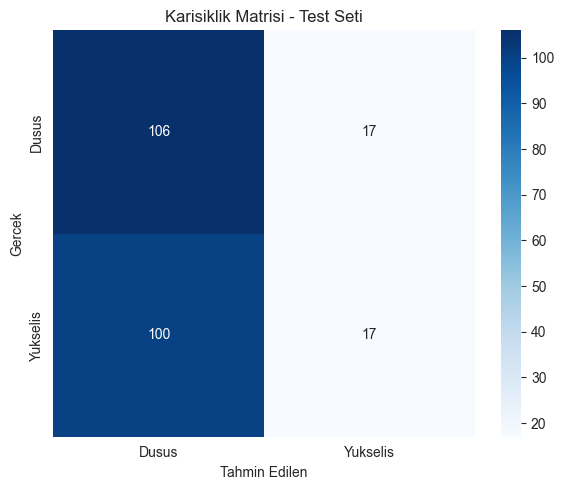

In [44]:
# Karisiklik matrisi (confusion matrix) gorsellestirmesi
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dusus", "Yukselis"], yticklabels=["Dusus", "Yukselis"], ax=ax)
ax.set_xlabel("Tahmin Edilen")
ax.set_ylabel("Gercek")
ax.set_title("Karisiklik Matrisi - Test Seti")
plt.tight_layout()
plt.show()


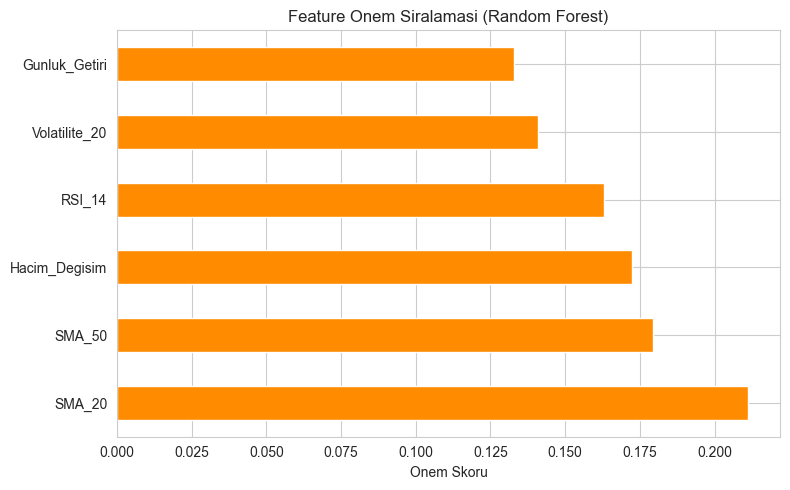

SMA_20           0.211350
SMA_50           0.179562
Hacim_Degisim    0.172313
RSI_14           0.162872
Volatilite_20    0.140890
Gunluk_Getiri    0.133014
dtype: float64


In [45]:
# Feature onem siralamasi - hangi gostergeler modelin kararinda daha etkili
onem = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
onem.plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Feature Onem Siralamasi (Random Forest)")
ax.set_xlabel("Onem Skoru")
plt.tight_layout()
plt.show()

print(onem)


**Yorum:** Model %51 doğruluk elde etmiş, bu da test setindeki çoğunluk sınıf oranına (~%51) eşit — yani model baseline'dan pratik olarak hiçbir fark göstermiyor. "Yükseliş" sınıfını yakalamada da çok zayıf kalmış (recall %15). Bu, başarısızlık değil; THYAO'nun kısa vadeli yön hareketinin basit teknik göstergelerle kolayca yakalanamadığını, piyasanın kısa vadede nispeten etkin davrandığını gösteren, beklenen ve savunulabilir bir sonuçtur.

## 9. Genel Sonuc ve Sinirlamalar

**Bulgular Ozeti:**

-THYAO'nun volatilitesi yıllara göre değişmiştir; 2021 ve 2023'te (hissenin ~15 TL'den ~300 TL bandına sıçradığı güçlü yükseliş dönemine denk gelen) yıllık volatilite %54-55 seviyesindeyken, 2024-2026'da fiyat daha yatay bir bant içinde hareket ettiğinden volatilite %29-35'e gerilemiştir.

-Hacim değişimi ile volatilite arasında zayıf-orta düzeyde pozitif bir ilişki (r≈0,31) bulunmuştur; golden cross ve death cross sonrası 10 günlük ortalama getiriler birbirine çok yakın çıkmıştır (%2,87 ve %2,52), bu da bu sinyallerin THYAO için net bir yön ayırt edici gücü olmadığını, genel yükseliş trendinin her iki sinyali de pozitif getiriye sürüklediğini göstermektedir.

-Random Forest sınıflandırma modeli test setinde %51 doğruluk elde etmiştir; bu değer test setindeki çoğunluk sınıf oranına (~%51) eşit olduğundan, model pratikte baseline'dan farksız kalmış ve özellikle "yükseliş" sınıfını yakalamakta başarısız olmuştur (recall %15) — bu sonuç, THYAO'nun kısa vadeli yön hareketinin basit teknik göstergelerle öngörülebilir olmadığını, piyasanın kısa vadede nispeten etkin davrandığını desteklemektedir.

**Sinirlamalar:**
- Analiz tek bir hisseye (THYAO) odaklanmistir, bulgular diger BIST hisselerine
  genellenemez.
- Kisa vadeli fiyat yonu tahmini, finansal piyasalarin yari-etkin yapisi
  nedeniyle dogasi geregi zordur; model sonuclari bu cerceve icinde
  degerlendirilmelidir.
- Kullanilan model kapsamli hiperparametre optimizasyonundan gecmemistir
  (proje gereksinimleri dogrultusunda tek savunulabilir model yeterli
  gorulmustur).
- Islem maliyetleri (komisyon, vergi, kayma/slippage) modele dahil
  edilmemistir; bu nedenle model bir "yatirim stratejisi" olarak degil,
  yalniz analitik bir alistirma olarak degerlendirilmelidir.

**Ogrenilenler:**

-Zaman serisi verisinde train/test ayrımının rastgele değil kronolojik yapılması gerektiğini öğrendim, çünkü rastgele karıştırma modelin gelecekteki veriyi dolaylı olarak "görmesine" (veri sızıntısı) yol açar.

-RSI hesaplamasında karşılaştığım inf hatası, formüllerin matematiksel sınır durumlarının (burada sıfıra bölme) kod düzeyinde gerçek bir hataya dönüşebileceğini gösterdi; bu yüzden veri temizliğinin sadece eksik (NaN) değil, sonsuz/gerçek dışı değerleri de kapsaması gerektiğini anladım.

-Bir modelin accuracy değerini, mutlaka baseline (çoğunluk sınıf tahmini) ile karşılaştırmadan yorumlamamak gerektiğini öğrendim — %51 doğruluk ilk bakışta makul görünse de, baseline ile aynı çıkması modelin gerçekte hiçbir şey öğrenmediğini ortaya koydu.

-AI'nin önerdiği yaklaşımları (örn. regresyon yerine sınıflandırma seçimi) kabul etmeden önce mantığını sorgulamanın, sonuçları doğru yorumlamak için gerekli olduğunu deneyimledim.